<a href="https://colab.research.google.com/github/ivanfajrinashrullah026/UTS-Data-Mining-/blob/main/UTS_DATA_MINING_IVAN_FAJRI_NASHRULLAH_2304020026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score # model evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

In [ ]:

data_training = pd.read_csv("data_training.csv")
data_training

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


fixed acidity: Tingkat keasaman tetap pada wine yang berasal dari asam non-volatil, seperti tartaric acid. Variabel ini berhubungan dengan karakter dasar rasa asam pada wine.

volatile acidity: Tingkat keasaman volatil pada wine, terutama dipengaruhi oleh acetic acid. Nilai yang terlalu tinggi dapat menurunkan kualitas wine karena menimbulkan aroma tajam seperti cuka.

citric acid: Kandungan asam sitrat pada wine. Variabel ini dapat memberikan rasa segar dan memengaruhi keseimbangan rasa.

residual sugar: Jumlah gula yang tersisa setelah proses fermentasi. Nilai ini dapat memengaruhi rasa manis pada wine.

chlorides: Kandungan garam atau klorida dalam wine. Nilai yang tinggi dapat memengaruhi rasa dan kualitas produk.

free sulfur dioxide: Jumlah sulfur dioksida bebas yang berfungsi membantu mencegah pertumbuhan mikroba dan oksidasi.

total sulfur dioxide: Total sulfur dioksida dalam wine, baik dalam bentuk bebas maupun terikat. Variabel ini berkaitan dengan stabilitas dan pengawetan wine.

density: Kepadatan wine yang dapat dipengaruhi oleh kadar alkohol dan gula. Nilai ini sering berkaitan dengan komposisi kimia wine.

pH: Tingkat keasaman wine pada skala pH. Nilai pH berpengaruh terhadap rasa, stabilitas, dan kualitas wine.

sulphates: Kandungan sulfat yang dapat membantu menjaga kualitas wine dan berperan dalam proses pengawetan.

alcohol: Kadar alkohol pada wine. Variabel ini sering menjadi salah satu faktor penting yang memengaruhi persepsi kualitas wine.

quality: Nilai kualitas wine yang menjadi variabel target klasifikasi. Pada dataset ini, quality dinyatakan dalam bentuk kelas numerik.

Id: Nomor identitas setiap data. Kolom ini hanya berfungsi sebagai penanda data, sehingga tidak digunakan sebagai variabel prediktor dalam proses pemodelan.

In [ ]:
data_training.quality.value_counts().sort_index()

,count
quality,
3,6
4,26
5,362
6,341
7,109
8,13


Imbalance class

Distribusi kelas pada variabel quality tidak sepenuhnya seimbang. Kelas kualitas tertentu memiliki jumlah data yang lebih banyak dibandingkan kelas lainnya, sehingga hasil evaluasi model perlu dibaca secara hati-hati, tidak hanya berdasarkan akurasi tetapi juga classification report.

In [ ]:
data_training.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


# Logistik Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:

x = data_training.drop(columns=["quality", "Id"])
y = data_training.quality

In [ ]:
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0
...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5


In [ ]:
y

,quality
0,5
1,5
2,7
3,6
4,6
...,...
852,4
853,5
854,6
855,6


In [ ]:
# split the dataset
# Stratify digunakan agar proporsi kelas quality pada data training dan testing tetap seimbang.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1, stratify=y
)

# Standardisasi dilakukan karena beberapa algoritma, seperti Logistic Regression, KNN, dan SVM,
# sensitif terhadap perbedaan skala antarvariabel.
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train), columns=x_train.columns, index=x_train.index
)
x_test_scaled = pd.DataFrame(
    scaler.transform(x_test), columns=x_test.columns, index=x_test.index
)
x_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
793,9.9,0.540,0.45,2.3,0.071,16.0,40.0,0.99910,3.39,0.62,9.4
35,8.2,0.280,0.60,3.0,0.104,10.0,22.0,0.99828,3.39,0.68,10.6
96,10.5,0.510,0.64,2.4,0.107,6.0,15.0,0.99730,3.09,0.66,11.8
705,9.2,0.590,0.24,3.3,0.101,20.0,47.0,0.99880,3.26,0.67,9.6
749,6.3,0.470,0.00,1.4,0.055,27.0,33.0,0.99220,3.45,0.48,12.3
...,...,...,...,...,...,...,...,...,...,...,...
477,9.9,0.400,0.53,6.7,0.097,6.0,19.0,0.99860,3.27,0.82,11.7
820,9.1,0.400,0.57,4.6,0.080,6.0,20.0,0.99652,3.28,0.57,12.5
514,8.8,0.700,0.00,1.7,0.069,8.0,19.0,0.99701,3.31,0.53,10.0
572,8.2,0.310,0.40,2.2,0.058,6.0,10.0,0.99536,3.31,0.68,11.2


In [ ]:
x_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
423,9.4,0.240,0.33,2.3,0.061,52.0,73.0,0.99786,3.47,0.90,10.2
500,8.6,0.635,0.68,1.8,0.403,19.0,56.0,0.99632,3.02,1.15,9.3
608,8.1,0.380,0.48,1.8,0.157,5.0,17.0,0.99760,3.30,1.05,9.4
130,9.0,0.360,0.52,2.1,0.111,5.0,10.0,0.99568,3.31,0.62,11.3
781,7.1,0.220,0.49,1.8,0.039,8.0,18.0,0.99344,3.39,0.56,12.4
...,...,...,...,...,...,...,...,...,...,...,...
570,12.6,0.410,0.54,2.8,0.103,19.0,41.0,0.99939,3.21,0.76,11.3
31,9.7,0.690,0.32,2.5,0.088,22.0,91.0,0.99790,3.29,0.62,10.1
536,7.2,0.520,0.07,1.4,0.074,5.0,20.0,0.99730,3.32,0.81,9.6
634,6.8,0.660,0.07,1.6,0.070,16.0,61.0,0.99572,3.29,0.60,9.3


In [ ]:
# Karena target quality memiliki lebih dari dua kelas, model yang digunakan adalah Multinomial Logit.
model = sm.MNLogit(y_train, sm.add_constant(x_train_scaled))
model_result = model.fit(method="newton", maxiter=200)

model_result.summary()

Optimization terminated successfully.
         Current function value: 0.907277
         Iterations 12


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                quality   No. Observations:                  599
Model:                        MNLogit   Df Residuals:                      539
Method:                           MLE   Df Model:                           55
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.2404
Time:                        08:18:36   Log-Likelihood:                -543.46
converged:                       True   LL-Null:                       -715.46
Covariance Type:            nonrobust   LLR p-value:                 1.979e-43
========================================================================================
           quality=4       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.2545      5.727      1.791      0.073      -0.970      21.479
fixed acidity            1.9045      2.795      0.681      0.496      -3.575       7.383
volatile acidity        -1.7531      1.141     -1.536      0.125      -3.990       0.484
citric acid             -4.0457      2.370     -1.707      0.088      -8.690       0.599
residual sugar          -0.4457      0.720     -0.619      0.536      -1.858       0.966
chlorides                0.8176      1.121      0.729      0.466      -1.380       3.016
free sulfur dioxide      3.2515      3.928      0.828      0.408      -4.447      10.950
total sulfur dioxide     1.9633      3.056      0.642      0.521      -4.027       7.954
density                 -0.9619      2.243     -0.429      0.668      -5.359       3.435
pH                      -2.0415      1.894     -1.078      0.281      -5.754       1.671
sulphates                0.9944      1.560      0.638      0.524      -2.062       4.051
alcohol                  3.3589      2.181      1.540      0.124      -0.915       7.633
----------------------------------------------------------------------------------------
           quality=5       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   13.4457      5.733      2.345      0.019       2.210      24.682
fixed acidity            0.7215      2.723      0.265      0.791      -4.616       6.059
volatile acidity        -2.3803      1.147     -2.075      0.038      -4.629      -0.132
citric acid             -3.6439      2.324     -1.568      0.117      -8.200       0.912
residual sugar          -0.8361      0.672     -1.245      0.213      -2.152       0.480
chlorides                0.5028      1.106      0.455      0.649      -1.664       2.670
free sulfur dioxide      3.5304      3.914      0.902      0.367      -4.142      11.202
total sulfur dioxide     2.3586      3.034      0.777      0.437      -3.589       8.306
density                 -0.3297      2.190     -0.151      0.880      -4.623       3.963
pH                      -3.0435      1.868     -1.629      0.103      -6.705       0.618
sulphates                0.3082      1.545      0.199      0.842      -2.720       3.336
alcohol                  3.0137      2.157      1.397      0.162      -1.213       7.240
----------------------------------------------------------------------------------------
           quality=6       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   13.6060      5.733      2.373      0.018       2.370      24.842
fixed acidity            1.1328      2.729      0.415      0.678      -4.216       6.481
volatile acidity        -3.0072      1.152     -2.609      0.009      -5.266      -0.748
citric acid             -4.1360      

In [ ]:
# Prediksi menghasilkan probabilitas untuk setiap kelas quality.
# Kelas akhir dipilih berdasarkan probabilitas terbesar.
pred_prob = model_result.predict(sm.add_constant(x_test_scaled))
label_map = {int(k): int(v) for k, v in model_result.model._ynames_map.items()}
pred = pred_prob.idxmax(axis=1).map(label_map).astype(int)
pred

,0
423,6
500,5
608,6
130,6
781,7
...,...
570,6
31,5
536,6
634,5


Prediksi di atas menghasilkan probabilitas untuk setiap kelas quality.
Kelas akhir dipilih berdasarkan probabilitas terbesar. Pada dataset sebelumnya, prediksi Logistic Regression dikonversi menggunakan ambang batas 0.5 karena targetnya berbentuk biner. Pada dataset data_training, target quality memiliki lebih dari dua kelas, sehingga pendekatan yang digunakan adalah memilih kelas dengan probabilitas prediksi tertinggi. Dengan demikian, model menghasilkan prediksi kelas kualitas wine seperti 3, 4, 5, 6, 7, atau 8.

In [ ]:
accuracy_score(y_test, pred) * 100

60.46511627906976

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred = logistic_model.predict(x_test_scaled)
pred

array([6, 5, 6, 6, 7, 7, 6, 6, 7, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 6, 5,
       5, 5, 5, 6, 5, 7, 5, 5, 6, 6, 5, 5, 5, 5, 5, 6, 5, 7, 6, 5, 5, 5,
       6, 5, 5, 5, 7, 6, 6, 6, 5, 6, 5, 6, 6, 5, 6, 6, 7, 5, 6, 6, 5, 6,
       5, 6, 6, 6, 5, 7, 6, 6, 6, 5, 6, 5, 5, 5, 5, 6, 6, 5, 6, 6, 6, 5,
       6, 6, 6, 5, 6, 5, 5, 5, 6, 5, 6, 6, 5, 6, 6, 5, 5, 6, 5, 6, 5, 5,
       5, 6, 5, 6, 6, 5, 5, 6, 5, 7, 5, 5, 5, 5, 5, 6, 7, 6, 5, 5, 5, 5,
       6, 6, 6, 6, 5, 5, 7, 6, 5, 6, 5, 6, 5, 5, 6, 7, 5, 7, 5, 5, 6, 6,
       6, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6, 6, 7, 7, 5, 6, 5, 5, 5, 5, 5, 5,
       7, 5, 5, 6, 5, 5, 7, 5, 5, 5, 6, 5, 6, 5, 5, 5, 6, 5, 6, 5, 7, 6,
       5, 6, 6, 6, 5, 7, 5, 5, 5, 5, 5, 6, 5, 6, 5, 6, 5, 6, 7, 5, 7, 5,
       6, 5, 5, 6, 6, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5,
       5, 5, 6, 6, 5, 6, 5, 5, 6, 5, 5, 6, 5, 6, 5, 5])

In [ ]:
x_test1 = x_test.copy()
x_test1['Quality_pred'] = pred
x_test1['Quality'] = y_test
x_test1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Quality_pred,Quality
423,9.4,0.240,0.33,2.3,0.061,52.0,73.0,0.99786,3.47,0.90,10.2,6,6
500,8.6,0.635,0.68,1.8,0.403,19.0,56.0,0.99632,3.02,1.15,9.3,5,5
608,8.1,0.380,0.48,1.8,0.157,5.0,17.0,0.99760,3.30,1.05,9.4,6,5
130,9.0,0.360,0.52,2.1,0.111,5.0,10.0,0.99568,3.31,0.62,11.3,6,6
781,7.1,0.220,0.49,1.8,0.039,8.0,18.0,0.99344,3.39,0.56,12.4,7,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,12.6,0.410,0.54,2.8,0.103,19.0,41.0,0.99939,3.21,0.76,11.3,6,6
31,9.7,0.690,0.32,2.5,0.088,22.0,91.0,0.99790,3.29,0.62,10.1,5,5
536,7.2,0.520,0.07,1.4,0.074,5.0,20.0,0.99730,3.32,0.81,9.6,6,6
634,6.8,0.660,0.07,1.6,0.070,16.0,61.0,0.99572,3.29,0.60,9.3,5,5


Menambahkan hasil prediksi model ke dalam dataset testing asli untuk membandingkan nilai quality hasil prediksi dengan nilai quality yang sebenarnya.

In [ ]:
accuracy_score(y_test, pred) * 100

61.240310077519375

Akurasi skor pada metode Logistic Regression menghasilkan akurasi senilai 61,240310077519375

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = knn_model.predict(x_test_scaled)
accuracy_score(y_test, y_pred) * 100

55.42635658914728

Akurasi skor pada metode KNN menghasilkan nilai akurasi senilai 55,42635658914728

In [ ]:
y_pred

array([6, 5, 6, 6, 7, 7, 7, 5, 7, 5, 5, 6, 5, 6, 5, 6, 5, 5, 6, 5, 6, 6,
       5, 6, 6, 5, 6, 5, 6, 5, 6, 5, 5, 6, 6, 6, 5, 6, 5, 7, 6, 5, 6, 5,
       6, 6, 5, 5, 7, 6, 6, 5, 5, 6, 5, 6, 6, 6, 6, 5, 7, 5, 6, 6, 5, 6,
       6, 6, 6, 5, 5, 6, 6, 6, 5, 6, 5, 5, 5, 6, 5, 6, 7, 5, 6, 6, 6, 5,
       5, 5, 7, 5, 6, 5, 5, 5, 5, 5, 6, 6, 5, 6, 6, 6, 6, 6, 5, 6, 6, 5,
       5, 6, 5, 6, 6, 5, 5, 7, 6, 7, 5, 5, 6, 5, 6, 6, 6, 6, 5, 5, 5, 6,
       5, 6, 5, 7, 5, 6, 7, 6, 5, 6, 6, 5, 6, 5, 5, 7, 5, 7, 6, 5, 5, 5,
       6, 5, 5, 5, 6, 6, 6, 6, 6, 5, 7, 6, 7, 5, 5, 6, 5, 5, 5, 6, 6, 6,
       7, 5, 5, 6, 5, 5, 7, 5, 5, 6, 6, 6, 6, 5, 6, 5, 7, 5, 6, 6, 7, 6,
       5, 6, 5, 6, 5, 7, 6, 6, 5, 5, 5, 6, 5, 6, 5, 6, 6, 6, 7, 5, 7, 5,
       6, 5, 5, 7, 6, 5, 5, 5, 5, 6, 6, 5, 5, 5, 5, 6, 5, 6, 5, 5, 5, 5,
       5, 6, 6, 6, 6, 6, 5, 6, 6, 5, 6, 6, 6, 5, 5, 5])

In [ ]:
neighbors_list = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
train_accuracy_list, test_accuracy_list = [], []

for neighbor_num in neighbors_list:
    knn_model = KNeighborsClassifier(n_neighbors=neighbor_num)
    knn_model.fit(x_train_scaled, y_train)

    train_pred = knn_model.predict(x_train_scaled)
    test_pred = knn_model.predict(x_test_scaled)
    train_acc_score = accuracy_score(y_train, train_pred) * 100
    test_acc_score = accuracy_score(y_test, test_pred) * 100

    train_accuracy_list.append(train_acc_score)
    test_accuracy_list.append(test_acc_score)
    print("Neighbors_num: {0} --> Accuracy on Test Set: {1} %".format(neighbor_num, np.round(test_acc_score, 2)))

Neighbors_num: 1 --> Accuracy on Test Set: 51.94 %
Neighbors_num: 3 --> Accuracy on Test Set: 51.94 %
Neighbors_num: 5 --> Accuracy on Test Set: 54.65 %
Neighbors_num: 7 --> Accuracy on Test Set: 55.43 %
Neighbors_num: 9 --> Accuracy on Test Set: 55.81 %
Neighbors_num: 11 --> Accuracy on Test Set: 56.98 %
Neighbors_num: 13 --> Accuracy on Test Set: 56.98 %
Neighbors_num: 15 --> Accuracy on Test Set: 57.36 %
Neighbors_num: 17 --> Accuracy on Test Set: 56.98 %
Neighbors_num: 19 --> Accuracy on Test Set: 55.04 %
Neighbors_num: 21 --> Accuracy on Test Set: 54.65 %


In [ ]:
performance_df = pd.DataFrame({
    'Neighbors_num' : neighbors_list,
    'Train Accuracy': train_accuracy_list,
    'Test Accuracy': test_accuracy_list
})
performance_df

,Neighbors_num,Train Accuracy,Test Accuracy
0,1,100.000000,51.937984
1,3,74.290484,51.937984
2,5,66.110184,54.651163
3,7,62.938230,55.426357
4,9,61.435726,55.813953
5,11,59.766277,56.976744
6,13,58.764608,56.976744
7,15,58.096828,57.364341
8,17,57.762938,56.976744
9,19,58.764608,55.038760


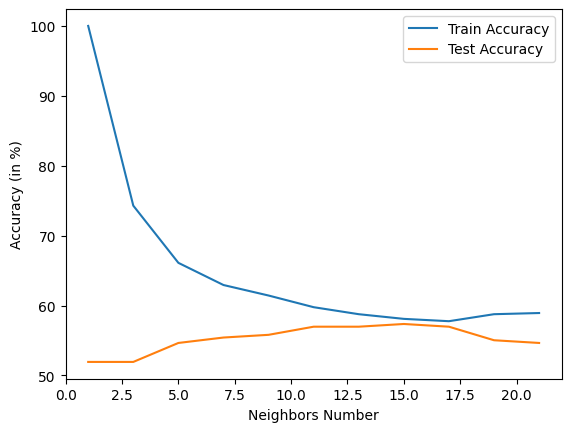

In [ ]:
plt.plot(
    performance_df['Neighbors_num'], performance_df['Train Accuracy'],
    performance_df['Neighbors_num'], performance_df['Test Accuracy']
)
plt.xlabel("Neighbors Number")
plt.ylabel("Accuracy (in %)")
plt.legend(['Train Accuracy', 'Test Accuracy'])
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[ 0  0  1  1  0  0]
 [ 0  0  5  3  0  0]
 [ 0  0 73 36  0  0]
 [ 0  0 33 58 11  0]
 [ 0  0  5 16 12  0]
 [ 0  0  0  2  2  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.62      0.67      0.65       109
           6       0.50      0.57      0.53       102
           7       0.48      0.36      0.41        33
           8       0.00      0.00      0.00         4

    accuracy                           0.55       258
   macro avg       0.27      0.27      0.27       258
weighted avg       0.52      0.55      0.54       258



# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing

In [ ]:
classifier = DecisionTreeClassifier(random_state=1)
classifier.fit(x_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
y_pred = classifier.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[ 0  0  1  1  0  0]
 [ 0  0  5  3  0  0]
 [ 2  2 60 44  0  1]
 [ 0  1 29 53 18  1]
 [ 0  2  6  9 16  0]
 [ 0  0  0  1  2  1]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.59      0.55      0.57       109
           6       0.48      0.52      0.50       102
           7       0.44      0.48      0.46        33
           8       0.33      0.25      0.29         4

    accuracy                           0.50       258
   macro avg       0.31      0.30      0.30       258
weighted avg       0.50      0.50      0.50       258



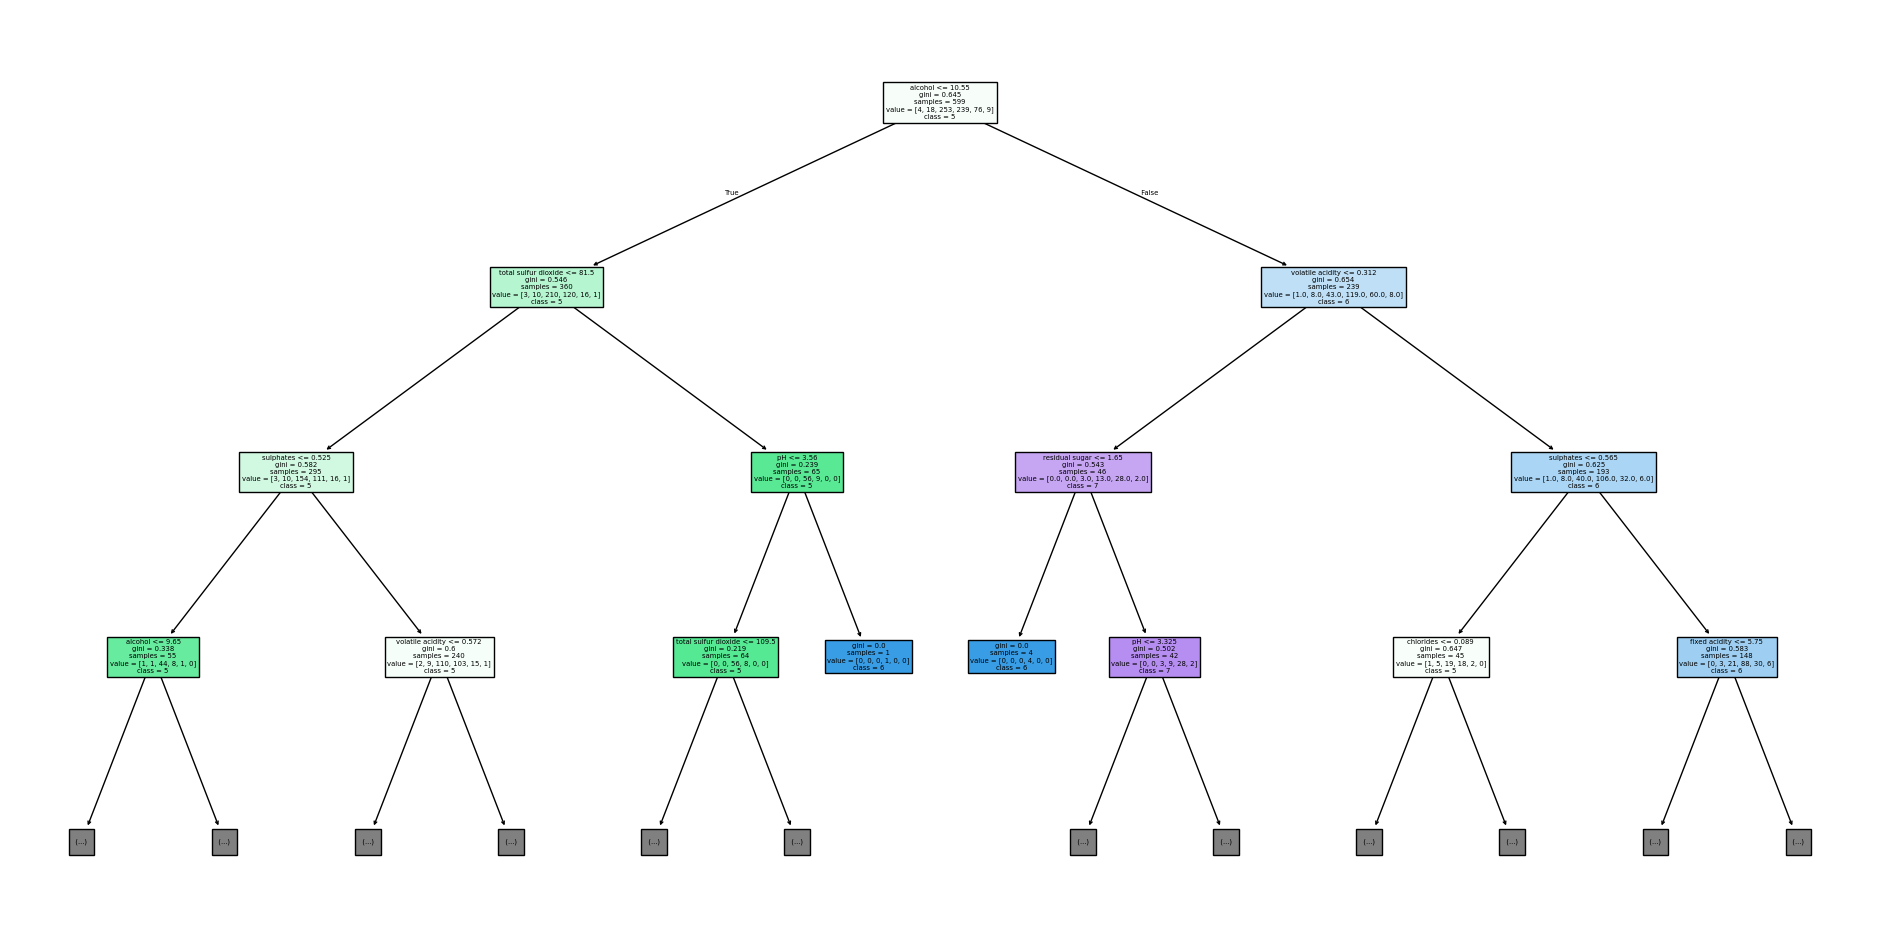

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(24, 12))
plot_tree(
    classifier.fit(x_train, y_train),
    filled=True,
    feature_names=x.columns,
    class_names=[str(label) for label in sorted(y.unique())],
    max_depth=3
)
plt.show()

In [ ]:
# import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# instantiate the classifier
rfc = RandomForestClassifier(n_estimators=10, random_state=0)

# fit the model
rfc.fit(x_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=0)

In [ ]:
# Predict the Test set results
y_pred = rfc.predict(x_test)
y_pred

array([6, 5, 6, 6, 5, 7, 7, 6, 7, 6, 5, 5, 5, 6, 7, 6, 5, 5, 6, 5, 6, 5,
       5, 5, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 6, 5, 6, 6, 5, 7, 6, 5, 5, 5,
       6, 5, 5, 5, 6, 7, 7, 5, 6, 6, 6, 6, 6, 5, 6, 6, 7, 5, 6, 6, 5, 6,
       6, 6, 6, 6, 5, 6, 6, 6, 5, 5, 5, 5, 5, 6, 5, 5, 6, 5, 6, 6, 5, 5,
       6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 6, 6, 5, 7, 6, 6, 5, 6, 5, 6, 5, 5,
       6, 6, 6, 5, 6, 5, 5, 7, 6, 6, 5, 5, 5, 5, 5, 5, 7, 5, 5, 5, 5, 5,
       6, 6, 6, 6, 5, 6, 6, 7, 5, 7, 5, 6, 5, 5, 5, 7, 5, 6, 6, 5, 5, 5,
       6, 6, 5, 5, 5, 5, 7, 6, 6, 6, 7, 6, 6, 5, 5, 6, 5, 6, 5, 5, 6, 5,
       6, 5, 5, 6, 5, 5, 6, 5, 5, 6, 6, 5, 6, 6, 5, 6, 6, 5, 7, 5, 7, 6,
       5, 5, 6, 6, 5, 7, 5, 5, 5, 5, 5, 6, 6, 5, 5, 7, 6, 5, 7, 5, 7, 5,
       8, 5, 5, 6, 6, 5, 5, 6, 5, 5, 7, 5, 5, 5, 5, 5, 5, 7, 5, 5, 6, 5,
       5, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5, 6, 5, 6, 5, 5])

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.6395


In [ ]:
# define the parameter list
max_depth_tree_list = np.arange(1, 20, 2)
tree_params_list = {
    'max_depth': max_depth_tree_list,
    'criterion': ['log_loss', 'gini', 'entropy'],
}

In [ ]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_grid=tree_params_list,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=1),
    scoring='accuracy'
)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=1, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=1),
             param_grid={'criterion': ['log_loss', 'gini', 'entropy'],
                         'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])},
             scoring='accuracy')

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='log_loss', max_depth=np.int64(1),
                       random_state=1)

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_best = best_model.predict(x_test)
y_best

array([5, 5, 5, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 5, 5, 5, 5, 5, 5, 6, 5,
       5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 6, 5, 5, 5,
       6, 5, 5, 5, 6, 5, 6, 5, 5, 6, 6, 6, 5, 5, 6, 6, 6, 5, 6, 6, 5, 6,
       6, 6, 6, 5, 5, 6, 6, 6, 6, 5, 6, 5, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5,
       6, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 6, 6, 5, 5, 5, 5, 6, 5, 5,
       6, 5, 5, 6, 6, 5, 5, 6, 5, 6, 5, 5, 5, 5, 5, 6, 6, 5, 5, 5, 5, 5,
       6, 6, 5, 6, 5, 6, 6, 5, 5, 5, 6, 5, 5, 5, 5, 6, 5, 6, 5, 5, 6, 5,
       6, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6, 6, 6, 5, 5, 6, 5, 5, 5, 5, 6, 5,
       6, 5, 6, 6, 5, 5, 6, 5, 5, 5, 5, 5, 6, 5, 5, 5, 6, 5, 5, 6, 6, 6,
       5, 5, 6, 6, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 5,
       6, 5, 5, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5,
       5, 5, 6, 6, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5, 5, 5])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_best))
print(classification_report(y_test, y_best, zero_division=0))

[[ 0  0  2  0  0  0]
 [ 0  0  6  2  0  0]
 [ 0  0 94 15  0  0]
 [ 0  0 52 50  0  0]
 [ 0  0  6 27  0  0]
 [ 0  0  1  3  0  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.58      0.86      0.70       109
           6       0.52      0.49      0.50       102
           7       0.00      0.00      0.00        33
           8       0.00      0.00      0.00         4

    accuracy                           0.56       258
   macro avg       0.18      0.23      0.20       258
weighted avg       0.45      0.56      0.49       258



# Support Vector Machine

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn import datasets
from sklearn.metrics import confusion_matrix

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn import svm

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=1)
ss = svm.SVC(class_weight=None, random_state=2)

# Parameter dibuat lebih ringkas agar proses GridSearch tidak terlalu berat,
# namun tetap mengikuti pola pencarian kernel, C, dan gamma seperti notebook awal.
parameter = {
    'kernel': ('linear', 'poly', 'rbf'),
    'C': [0.001, 0.01, 0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(ss, parameter, cv=cv, n_jobs=1, scoring='accuracy')
grid.fit(x_train_scaled, y_train)
grid.best_params_

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

In [ ]:
from sklearn import svm
svm_model = svm.SVC(
    class_weight=None,
    C=grid.best_params_['C'],
    gamma=grid.best_params_['gamma'],
    kernel=grid.best_params_['kernel'],
    random_state=100
)

n = 5
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=n, shuffle=True, random_state=1)

In [ ]:
svm_model.fit(x_train_scaled, y_train)
y_pred = svm_model.predict(x_test_scaled)
y_pred

array([6, 5, 6, 6, 6, 7, 6, 6, 7, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 6, 5,
       5, 5, 5, 6, 6, 6, 5, 5, 6, 6, 5, 5, 5, 5, 5, 6, 5, 7, 6, 5, 5, 5,
       6, 5, 5, 5, 6, 6, 6, 6, 6, 6, 5, 6, 6, 5, 6, 5, 6, 5, 6, 6, 6, 6,
       5, 6, 6, 6, 5, 6, 6, 6, 5, 5, 5, 5, 5, 6, 5, 6, 6, 5, 6, 6, 6, 5,
       6, 6, 6, 5, 6, 5, 5, 5, 6, 5, 6, 6, 5, 6, 6, 5, 5, 6, 5, 6, 6, 5,
       5, 6, 5, 6, 6, 5, 5, 6, 5, 7, 5, 5, 6, 5, 5, 6, 6, 6, 5, 5, 5, 5,
       6, 6, 6, 6, 5, 5, 6, 6, 6, 7, 6, 6, 5, 5, 5, 7, 5, 7, 5, 5, 6, 5,
       6, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6, 6, 6, 5, 5, 6, 5, 5, 5, 5, 6, 5,
       6, 5, 5, 6, 5, 5, 6, 5, 5, 5, 6, 5, 6, 5, 5, 5, 6, 5, 6, 5, 6, 6,
       5, 6, 6, 6, 5, 7, 5, 5, 5, 5, 5, 6, 6, 6, 5, 6, 5, 6, 7, 5, 6, 5,
       6, 5, 5, 6, 6, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5,
       5, 5, 6, 6, 5, 6, 5, 5, 6, 5, 6, 6, 5, 6, 5, 5])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[ 0  0  2  0  0  0]
 [ 0  0  7  1  0  0]
 [ 0  0 91 18  0  0]
 [ 0  0 33 66  3  0]
 [ 0  0  2 27  4  0]
 [ 0  0  0  2  2  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         8
           5       0.67      0.83      0.75       109
           6       0.58      0.65      0.61       102
           7       0.44      0.12      0.19        33
           8       0.00      0.00      0.00         4

    accuracy                           0.62       258
   macro avg       0.28      0.27      0.26       258
weighted avg       0.57      0.62      0.58       258



In [ ]:
# Akurasi akhir model SVM pada data testing
accuracy_score(y_test, y_pred) * 100

62.4031007751938

Akurasi skor pada metode Suppot Vector Machine menghasilkan nilai akurasi skor sebesar 62,4031007751938

# Penyimpanan dan Deployment Model SVM

Pada tahap ini, model yang digunakan untuk deployment adalah Support Vector Machine (SVM). Model SVM dipilih berdasarkan keputusan penelitian, kemudian disimpan agar dapat digunakan kembali tanpa harus melatih model dari awal. Karena model SVM pada notebook ini menggunakan data yang sudah distandardisasi, maka scaler dan model disimpan dalam satu pipeline agar proses prediksi pada data testing tetap konsisten dengan data training.

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

# Menentukan parameter terbaik SVM.

try:
    best_svm_params = grid.best_params_
except NameError:
    best_svm_params = {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

best_svm_params

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Model akhir dilatih kembali menggunakan seluruh data training. Langkah ini dilakukan karena pada tahap deployment, tujuan utamanya bukan lagi membandingkan performa antar model, melainkan menggunakan seluruh informasi dari data training untuk menghasilkan prediksi pada data testing yang belum memiliki label quality.

In [ ]:
# Kolom quality digunakan sebagai target, sedangkan Id tidak digunakan sebagai fitur.
feature_columns = [col for col in data_training.columns if col not in ['quality', 'Id']]
target_column = 'quality'
id_column = 'Id'

X_final = data_training[feature_columns]
y_final = data_training[target_column]

# Pipeline digunakan agar standardisasi dan model SVM tersimpan dalam satu alur.
final_svm_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('svm', svm.SVC(
        class_weight=None,
        C=best_svm_params['C'],
        gamma=best_svm_params['gamma'],
        kernel=best_svm_params['kernel'],
        random_state=100
    ))
])

final_svm_pipeline.fit(X_final, y_final)
final_svm_pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, gamma=0.01, random_state=100))])

In [ ]:
# Menyimpan model SVM agar dapat digunakan kembali untuk deployment.
model_package = {
    'model': final_svm_pipeline,
    'feature_columns': feature_columns,
    'target_column': target_column,
    'id_column': id_column,
    'best_params': best_svm_params
}

joblib.dump(model_package, 'svm_quality_model.pkl')
print('Model SVM berhasil disimpan sebagai svm_quality_model.pkl')

Model SVM berhasil disimpan sebagai svm_quality_model.pkl


# Deployment Model SVM pada Dataset Testing

Dataset testing dibaca sebagai data baru yang akan diprediksi menggunakan model SVM yang sudah disimpan. Pada data testing tidak terdapat kolom quality, sehingga output utama dari tahap ini adalah kolom Quality_pred sebagai hasil prediksi kualitas wine.

In [ ]:
# Membaca dataset testing yang sudah disediakan.

data_testing = pd.read_csv('data_testing.csv')
data_testing

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


In [ ]:
# Memuat kembali model SVM yang sudah disimpan.
loaded_package = joblib.load('svm_quality_model.pkl')
loaded_svm_model = loaded_package['model']
feature_columns = loaded_package['feature_columns']

# Mengambil fitur pada data testing sesuai urutan fitur saat training.
X_deployment = data_testing[feature_columns]

# Melakukan prediksi quality pada dataset testing.
quality_prediction = loaded_svm_model.predict(X_deployment)
quality_prediction

array([5, 5, 5, 5, 6, 6, 5, 5, 6, 5, 7, 6, 5, 6, 6, 5, 6, 5, 5, 6, 6, 7,
       5, 6, 5, 5, 6, 6, 5, 6, 6, 6, 7, 6, 6, 5, 5, 6, 7, 5, 6, 5, 7, 5,
       5, 5, 6, 6, 5, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 5, 5, 6, 6, 6, 6, 5,
       6, 5, 5, 6, 5, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 6, 6, 5, 5, 6, 5, 6,
       6, 5, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 6,
       6, 5, 5, 6, 5, 5, 6, 6, 6, 5, 5, 5, 5, 5, 5, 6, 6, 6, 5, 6, 5, 5,
       7, 6, 7, 5, 5, 5, 6, 6, 7, 5, 5, 5, 6, 5, 5, 5, 5, 5, 6, 5, 6, 5,
       6, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 5, 5, 5,
       6, 6, 6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 5, 6,
       7, 6, 6, 6, 5, 5, 6, 5, 5, 5, 6, 6, 5, 6, 5, 6, 5, 5, 6, 5, 6, 6,
       6, 6, 5, 6, 5, 6, 5, 5, 6, 6, 6, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 6,
       6, 5, 6, 6, 5, 6, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 6, 6, 6, 6,
       5, 5, 6, 6, 5, 6, 5, 7, 5, 6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 5, 6, 7])

In [ ]:
# Menambahkan hasil prediksi ke dataset testing.
hasil_prediksi_svm = data_testing.copy()
hasil_prediksi_svm['Quality_pred'] = quality_prediction
hasil_prediksi_svm

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id,Quality_pred
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222,5
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514,5
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417,5
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754,5
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147,6
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296,5
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170,5
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439,6


In [ ]:
# Melihat distribusi hasil prediksi quality pada data testing.
hasil_prediksi_svm['Quality_pred'].value_counts().sort_index()

,count
Quality_pred,
5,129
6,146
7,11


In [ ]:
# Menyimpan hasil deployment ke dalam file CSV.
hasil_prediksi_svm.to_csv('hasil_prediksi_svm_data_testing.csv', index=False)
print('Hasil prediksi berhasil disimpan sebagai hasil_prediksi_svm_data_testing.csv')

Hasil prediksi berhasil disimpan sebagai hasil_prediksi_svm_data_testing.csv
